## Exercise 1

When throwing two fair dice the probabilites of possible values are


<table style="border-collapse: collapse; width: 35.8719%;" border="1">
<tbody>
<tr>
<td style="width: 15.0794%;">2 or 12</td>
<td style="width: 20.7936%;">1/36 = 2.8%</td>
</tr>
<tr>
<td style="width: 15.0794%;">3 or 11</td>
<td style="width: 20.7936%;">2/36 = 5.6%</td>
</tr>
<tr>
<td style="width: 15.0794%;">4 or 10</td>
<td style="width: 20.7936%;">3/36 = 8.3%</td>
</tr>
<tr>
<td style="width: 15.0794%;">5 or 9</td>
<td style="width: 20.7936%;">4/36 = 11.1%</td>
</tr>
<tr>
<td style="width: 15.0794%;">6 or 8</td>
<td style="width: 20.7936%;">5/36 = 13.9%</td>
</tr>
<tr>
<td style="width: 15.0794%;">7</td>
<td style="width: 20.7936%;">6/36 = 16.7%</td>
</tr>
</tbody>
</table>

<br>

The histogram looks like this.
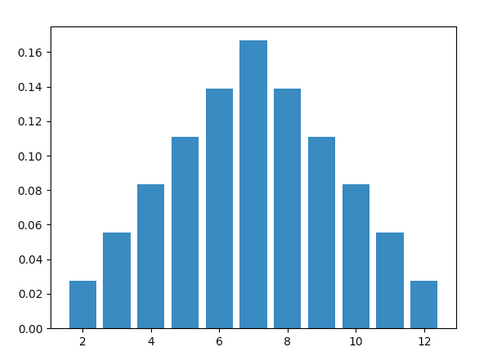
 

1- Write a `for` loop which repeats the steps 1)-3) below for values of `n` ranging as

500, 1000, 2000, 5000, 10000, 15000, 20000, 50000, 100000

2- Use numpy to simulate throwing of two dice n` times. Compute the sum of the dice.

3- Use numpys `histogram()` function to compute the frequencies as

`h,h2 = np.histogram(s,range(2,14))`
where s contains the sum.

4- Use matplotlib's bar function to plot the histogram as

`plt.bar(h2[:-1],h/n)`

and show the value of `n` in the title.

5- What do you observe? You may need to run the loop a few times to see it.

6- How is this related to "regression to the mean"?

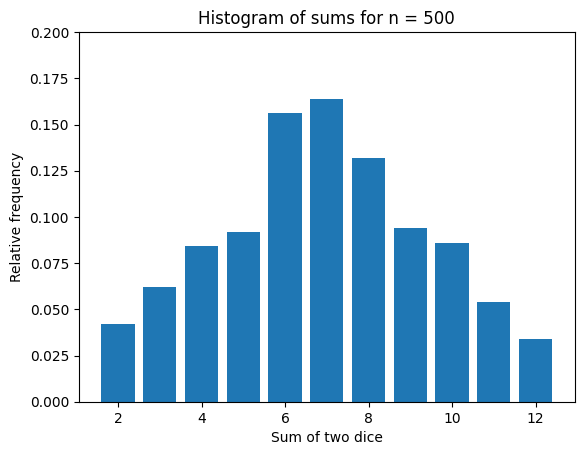

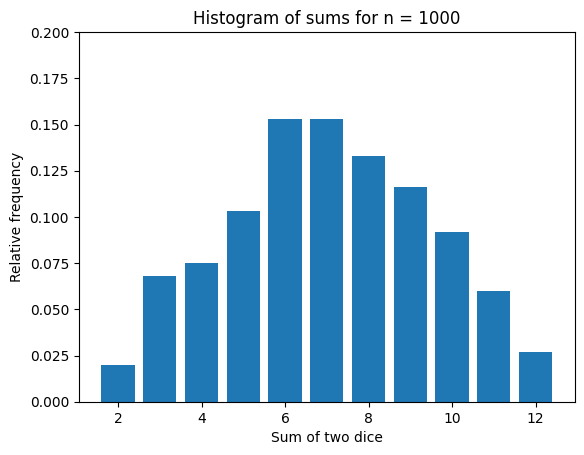

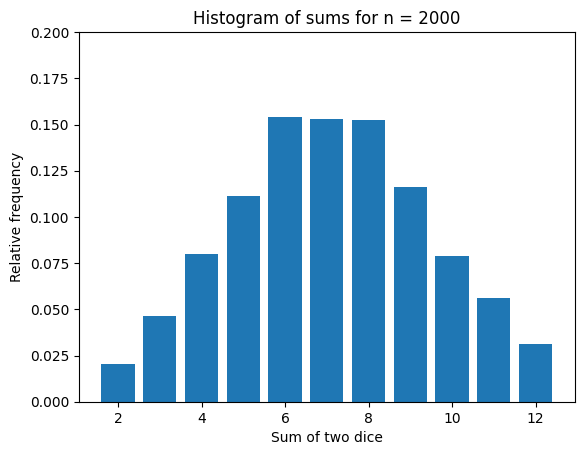

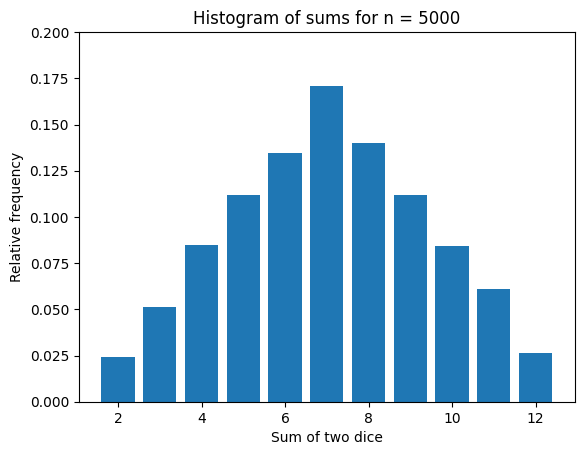

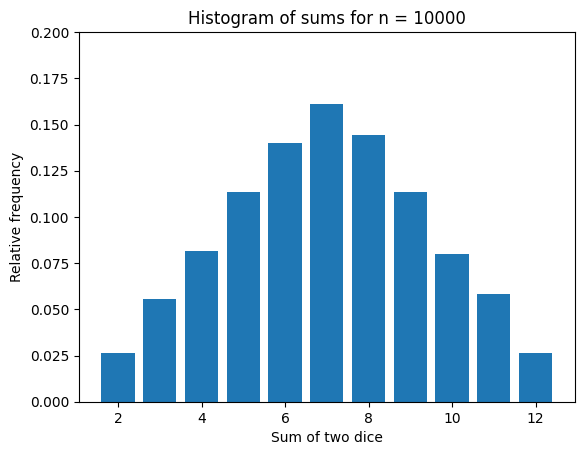

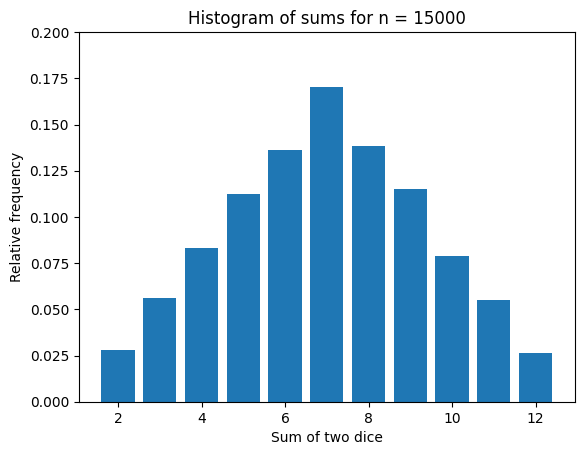

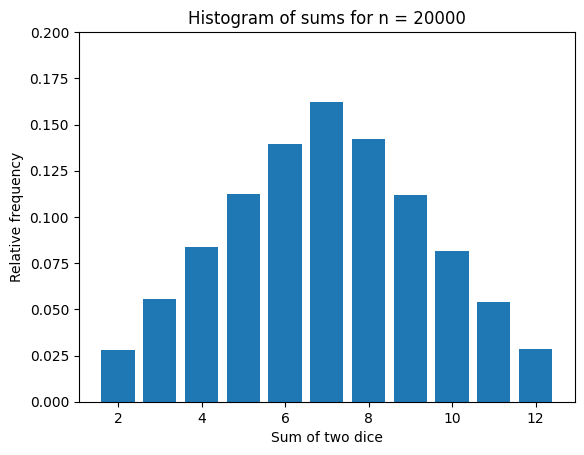

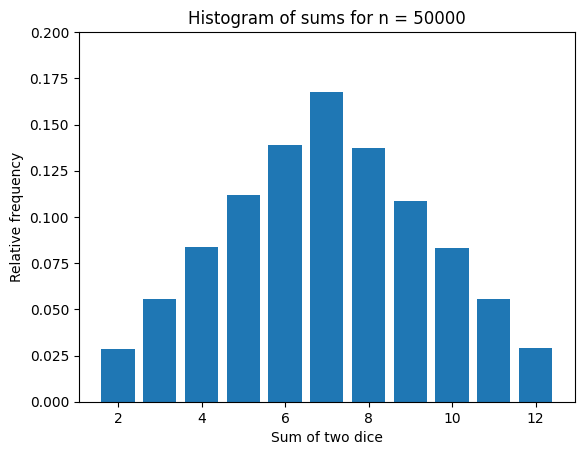

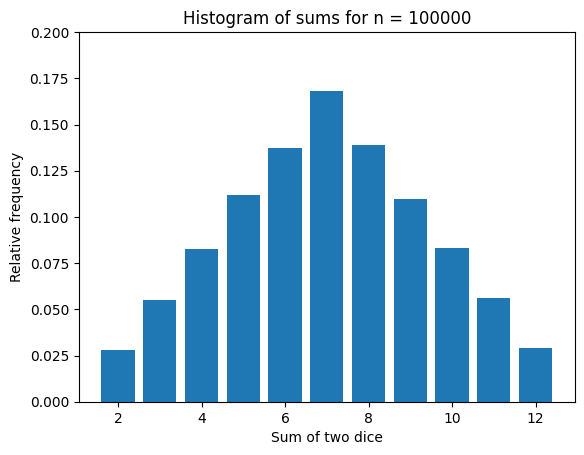

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# values of n
n_values = [500, 1000, 2000, 5000, 10000, 15000, 20000, 50000, 100000]

for n in n_values:
    # 2) simulate throwing two dice n times
    # each die: integers 1..6
    dice1 = np.random.randint(1, 7, size=n)
    dice2 = np.random.randint(1, 7, size=n)
    s = dice1 + dice2          # sum of the dice

    # 3) histogram frequencies
    h, h2 = np.histogram(s, range(2, 14))   # bin edges in h2, counts in h

    # 4) plot
    plt.figure()
    plt.bar(h2[:-1], h / n)    # divide by n to get relative frequency
    plt.xlabel("Sum of two dice")
    plt.ylabel("Relative frequency")
    plt.title(f"Histogram of sums for n = {n}")
    plt.ylim(0, 0.2)
    plt.show()

## Exercise 2

Consider the data from the file weight-height.csv.

1- Inspect the dependence between height and weight using a scatter plot. You may use either of the variables as independent variable.

2- Choose appropriate model for the dependence

3- Perform regression on the data using your model of choice

4- Plot the results

5- Compute RMSE and R2 value

6- Assess the quality of the regression (visually and using numbers) in your own words.

You are not required to split the dataset into training and testing sets. Of course you are completely free to experiment it here already.

It is recommended that you use the module sklearn for all your computations.

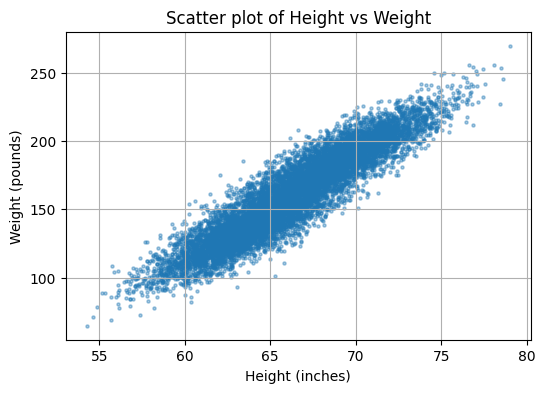

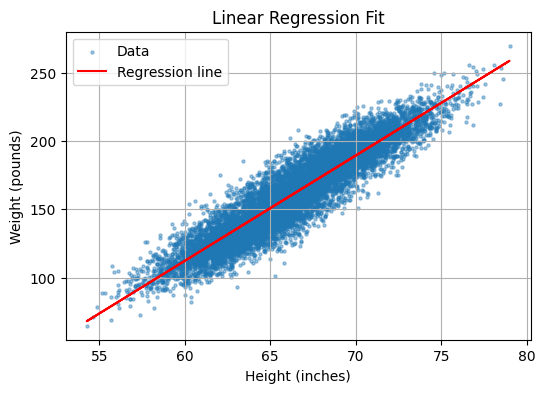

RMSE: 12.218571272826035
R²: 0.8551742120609958


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("weight-height.csv")

height = df["Height"].values.reshape(-1, 1)   # independent variable
weight = df["Weight"].values                 # dependent variable

plt.figure(figsize=(6,4))
plt.scatter(height, weight, s=5, alpha=0.4)
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")
plt.title("Scatter plot of Height vs Weight")
plt.grid(True)
plt.show()

model = LinearRegression()
model.fit(height, weight)

# Predictions
weight_pred = model.predict(height)

plt.figure(figsize=(6,4))
plt.scatter(height, weight, s=5, alpha=0.4, label="Data")
plt.plot(height, weight_pred, color="red", label="Regression line")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

rmse = np.sqrt(mean_squared_error(weight, weight_pred))
r2 = r2_score(weight, weight_pred)

print("RMSE:", rmse)
print("R²:", r2)